# Notebook 2 - Modelisation et optimisation

## Objectif du notebook

Ce notebook a pour role de transformer le dataset prepare en resultats de modelisation exploitables :
- comparer plusieurs modeles supervises ;
- evaluer leurs performances sur les deux cibles ;
- selectionner un modele pertinent pour chaque cible ;
- optimiser le meilleur modele selon la metrique retenue ;
- mesurer l'impact de `ENERGYSTARScore` ;
- interpreter les variables les plus influentes.

## Demarche suivie

### 1. Chargement du dataset final
- [x] Chargement de `df_modele.csv`
- [x] Controle de la structure finale du DataFrame
- [x] Verification des cibles et des types de variables

### 2. Preparation des variables explicatives
- [x] Separation des deux cibles : `EnergyTarget` et `CO2Target`
- [x] Encodage cible des variables categorielles
- [x] Creation d'un split unique `90% / 10%`
- [x] Conservation du meme hold-out final pour comparer les versions avec et sans `ENERGYSTARScore`

### 3. Benchmark des modeles
- [x] Comparaison de plusieurs modeles sur `EnergyTarget`
- [x] Comparaison de plusieurs modeles sur `CO2Target`
- [x] Validation croisee (`cv=5`) pour comparer les modeles de facon plus robuste
- [x] Lecture des metriques : `R2`, `MAE`, `RMSE`, `MAPE`

### 4. Selection et optimisation des modeles
- [x] Selection de `Random Forest` pour `EnergyTarget`
- [x] Optimisation de `Random Forest` via `GridSearchCV` sur le `MAE`
- [x] Selection de `Random Forest` pour `CO2Target` lorsque le `MAE` est la metrique prioritaire
- [x] Optimisation de `Random Forest` via `GridSearchCV` sur le `MAE`

### 5. Evaluation finale sur hold-out
- [x] Test final sans `ENERGYSTARScore`
- [x] Test final avec `ENERGYSTARScore`
- [x] Comparaison stricte a split constant
- [x] Mesure du gain reel lie a `ENERGYSTARScore`

### 6. Interpretation
- [x] Importance des variables pour `Random Forest` sur `EnergyTarget`
- [x] Importance des variables pour `Random Forest` sur `CO2Target`
- [x] Analyse de l'apport de `ENERGYSTARScore`



# Notebook support pour projet ML modèle supervisé
## NoteBook 2 - Modélisations & Optimisations

<u>Dans l'ordre nous allons suivre ces étapes :</u> 
1) Charger le DataFrame travaillé dans le Notebook 1 (Données nettoyées, analysées, feature engineering réalisé),
2) Tester différents modèles de ML supervisé pour chaque target, 
3) Mesurer les performances des modèles testés,
4) Choix du ou des modèles les plus performants pour les deux targets,
5) Optimisation des modèles selectionnés


In [58]:
import importlib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import Fonctions_MODEL
importlib.reload(Fonctions_MODEL)
from Fonctions_MODEL import evaluate_regression_model_cv
from Fonctions_EDA import eda_overview

df = pd.read_csv("df_modele.csv")

eda_overview(df)

target_cols = [
    "EnergyTarget",
    "CO2Target"
]

num_cols = [
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "ENERGYSTARScore",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFAParking",
    "BuildingAge",
    "GFA_per_floor",
    "BuildingGFARatio",
    "ParkingRatio",
    "LargestUseRatio",
    "SecondUseRatio",
    "ThirdUseRatio",
    "UseTypesCount"
]

bool_cols = [
    "HasEnergyStarScore",
    "UsesElectricity", 
    "UsesGas",
    "UsesSteam"
]

cat_cols = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
    "BuildingAgeCat",
    "SizeCategory"
    ]

## 1) Vue globale

,n_lignes,n_colonnes,doublons,%_doublons
0,1276,26,0,0.0


## 2) Qualité des colonnes et cardinalité

,dtype,%null,non_null,null,n_uniques
ENERGYSTARScore,float64,33.86,844,432,100
EnergyTarget,float64,0.00,1276,0,1276
CO2Target,float64,0.00,1276,0,1233
LargestPropertyUseTypeGFA,float64,0.00,1276,0,1209
SecondLargestPropertyUseTypeGFA,float64,0.00,1276,0,602
ThirdLargestPropertyUseTypeGFA,float64,0.00,1276,0,259
NumberofBuildings,float64,0.00,1276,0,10
GFA_per_floor,float64,0.00,1276,0,1244
BuildingGFARatio,float64,0.00,1276,0,288
LargestUseRatio,float64,0.00,1276,0,879


## 3) Variables numériques (21)

...

,%outliers (IQR),nb_outliers_bas,nb_outliers_haut,min,Q1,median,Q3,max,skew,kurtosis
PropertyGFAParking,22.73,0,290,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,5.126080e+05,4.791472,29.380927
BuildingGFARatio,22.73,290,0,0.201833,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-2.219444,4.610003
ThirdUseRatio,21.63,0,276,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.897959e-01,3.266243,12.098166
ThirdLargestPropertyUseTypeGFA,21.63,0,276,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.039100e+05,12.262989,206.878271
SecondLargestPropertyUseTypeGFA,12.85,0,164,0.000000,0.000000e+00,1.321000e+03,1.441300e+04,3.898600e+05,4.338477,22.172973
EnergyTarget,11.36,0,145,318703.187500,1.413803e+06,2.766299e+06,6.641699e+06,1.232056e+08,4.442002,28.117394
CO2Target,10.82,0,138,2.520000,2.247500e+01,4.910500e+01,1.207550e+02,3.243480e+03,6.916478,69.093815
LargestPropertyUseTypeGFA,10.58,0,135,5656.000000,2.432625e+04,4.138500e+04,8.889125e+04,1.719643e+06,5.199739,36.419262
UsesSteam,7.37,0,94,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.267889,8.692718
GFA_per_floor,7.21,0,92,3294.545455,1.259967e+04,2.150051e+04,3.492925e+04,1.100000e+06,10.870941,191.408741


## 4) Variables catégorielles (5)

,n_uniques,null,%null,modalite_top,nb_modalite_top
SecondLargestPropertyUseType,46,0,0.0,No_Second_Use,563
ThirdLargestPropertyUseType,37,0,0.0,No_Third_Use,980
PrimaryPropertyType,21,0,0.0,Small- and Mid-Sized Office,267
Neighborhood,19,0,0.0,DOWNTOWN,306
BuildingType,5,0,0.0,NonResidential,1184


## 5) Variables temporelles (0)

_Aucune variable datetime._

In [59]:
df.shape
df.columns

Index(['EnergyTarget', 'CO2Target', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA',
       'ENERGYSTARScore', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFAParking', 'BuildingAge', 'GFA_per_floor',
       'BuildingGFARatio', 'LargestUseRatio', 'SecondUseRatio',
       'ThirdUseRatio', 'BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType',
       'BuildingAgeCat', 'SizeCategory', 'HasEnergyStarScore',
       'UsesElectricity', 'UsesGas', 'UsesSteam'],
      dtype='str')

Pour une première analyse de performance des modèles, nous allons prendre les variables suivantes : 

(On exclut volontairement ENERGYScore pour l'instant).

### On sépare nos jeux de données Train / Evaluation / Test

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder

target1 = "EnergyTarget"
target2 = "CO2Target"
ENERGYScore = ["ENERGYSTARScore", "HasEnergyStarScore"]

# 1) Base features
X = df.drop(columns=[target1, target2]).copy()
y1 = df[target1].copy()
y2 = df[target2].copy()

# 2) Split unique AVANT encodage (anti-leakage)
X_eva_full, X_final_full, y1_eva, y1_final, y2_eva, y2_final = train_test_split(
    X,
    y1,
    y2,
    test_size=0.10,
    random_state=42,
)

def fit_transform_cat(train_df, test_df, col_name, encoding_type):
    train_df = train_df.copy()
    test_df = test_df.copy()

    if encoding_type == "onehot":
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

        train_encoded = pd.DataFrame(
            encoder.fit_transform(train_df[[col_name]]),
            columns=encoder.get_feature_names_out([col_name]),
            index=train_df.index,
        )
        test_encoded = pd.DataFrame(
            encoder.transform(test_df[[col_name]]),
            columns=encoder.get_feature_names_out([col_name]),
            index=test_df.index,
        )

    elif encoding_type == "binary":
        encoder = BinaryEncoder(cols=[col_name])
        train_encoded = encoder.fit_transform(train_df[[col_name]])
        test_encoded = encoder.transform(test_df[[col_name]])
    else:
        raise ValueError("encoding_type doit être 'onehot' ou 'binary'.")

    train_df = pd.concat([train_df.drop(columns=[col_name]), train_encoded], axis=1)
    test_df = pd.concat([test_df.drop(columns=[col_name]), test_encoded], axis=1)
    return train_df, test_df

# One-hot sur colonnes nominales choisies
for col in ["BuildingType", "MainEnergySource"]:
    if col in X_eva_full.columns:
        X_eva_full, X_final_full = fit_transform_cat(X_eva_full, X_final_full, col, "onehot")

# Binary encoding sur le reste des catégorielles
remaining_cat_cols = X_eva_full.select_dtypes(include=["object", "string", "category"]).columns.tolist()
for col in remaining_cat_cols:
    X_eva_full, X_final_full = fit_transform_cat(X_eva_full, X_final_full, col, "binary")

# 3) Version sans ENERGYScore, sur les MEMES lignes
X_eva_no_energy = X_eva_full.drop(columns=ENERGYScore, errors="ignore").copy()
X_final_no_energy = X_final_full.drop(columns=ENERGYScore, errors="ignore").copy()

# 4) Version avec ENERGYScore
X_eva_with_energy = X_eva_full.copy()
X_final_with_energy = X_final_full.copy()

# X_final_no_energy / with_energy et y*_final servent uniquement à l'évaluation finale


In [61]:
X_eva_full.columns

Index(['LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking',
       'BuildingAge', 'GFA_per_floor', 'BuildingGFARatio', 'LargestUseRatio',
       'SecondUseRatio', 'ThirdUseRatio', 'BuildingAgeCat', 'SizeCategory',
       'HasEnergyStarScore', 'UsesElectricity', 'UsesGas', 'UsesSteam',
       'BuildingType_Campus', 'BuildingType_NonResidential',
       'BuildingType_Nonresidential COS', 'BuildingType_Nonresidential WA',
       'BuildingType_SPS-District K-12', 'PrimaryPropertyType_0',
       'PrimaryPropertyType_1', 'PrimaryPropertyType_2',
       'PrimaryPropertyType_3', 'PrimaryPropertyType_4', 'Neighborhood_0',
       'Neighborhood_1', 'Neighborhood_2', 'Neighborhood_3', 'Neighborhood_4',
       'SecondLargestPropertyUseType_0', 'SecondLargestPropertyUseType_1',
       'SecondLargestPropertyUseType_2', 'SecondLargestPropertyUseType_3',
       'Sec

In [62]:
X_final_full.shape

(128, 46)

### Définition des modèles que nous allons tester :

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import Fonctions_MODEL
importlib.reload(Fonctions_MODEL)
from Fonctions_MODEL import print_cv_results

models = {
    "Dummy": Pipeline([("imputer", SimpleImputer(strategy="median")),("dummy", DummyRegressor())]),

    "Linear Regression": Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()),("lr", LinearRegression())]),

    "Polynomial Regression": Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()),("poly", PolynomialFeatures(degree=2, include_bias=False)),("lr", LinearRegression())]),

    "Ridge": Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()),("ridge", Ridge())]),

    "Lasso": Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()),("lasso", Lasso())]),

    "ElasticNet": Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()),("elasticnet", ElasticNet())]),

    "SVR": Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()),("svr", SVR())]),

    "Random Forest": Pipeline([("imputer", SimpleImputer(strategy="median")),("rf", RandomForestRegressor(random_state=42))]),

    "XGBoost": Pipeline([("imputer", SimpleImputer(strategy="median")),("xgb", XGBRegressor(random_state=42))]),
}

print_cv_results(models, X_eva_no_energy, y1_eva, cv=5, inverse_target_func=None)



Dummy
Train | R²: 0.0000 | MAPE: 252.19% | MAE: 6077767.8622 | RMSE: 10588527.4806
Test  | R²: -0.0093 | MAPE: 252.64% | MAE: 6094835.6791 | RMSE: 10444550.8577

Linear Regression
Train | R²: 0.8172 | MAPE: 67.41% | MAE: 2468965.8456 | RMSE: 4520598.6915
Test  | R²: 0.7539 | MAPE: 70.16% | MAE: 2711397.9950 | RMSE: 5102270.9572

Polynomial Regression
Train | R²: 0.9934 | MAPE: 25.86% | MAE: 497273.7292 | RMSE: 860173.0376
Test  | R²: -1230.5010 | MAPE: 2764.61% | MAE: 72249220.7158 | RMSE: 225189278.7243

Ridge
Train | R²: 0.8172 | MAPE: 67.36% | MAE: 2468041.6133 | RMSE: 4520638.1343
Test  | R²: 0.7544 | MAPE: 70.11% | MAE: 2709843.1944 | RMSE: 5097826.9846

Lasso
Train | R²: 0.8172 | MAPE: 67.41% | MAE: 2468964.3505 | RMSE: 4520598.6915
Test  | R²: 0.7539 | MAPE: 70.15% | MAE: 2711094.2830 | RMSE: 5102226.5193

ElasticNet
Train | R²: 0.7769 | MAPE: 70.14% | MAE: 2589436.8442 | RMSE: 4998263.9142
Test  | R²: 0.7492 | MAPE: 71.93% | MAE: 2700191.1146 | RMSE: 5218969.4267

SVR
Train | 

In [64]:
print("target1:", target1, "target2:", target2)
print("y1 range:", y1.min(), y1.max())
print("y2 range:", y2.min(), y2.max())

target1: EnergyTarget target2: CO2Target
y1 range: 318703.1875 123205560.0
y2 range: 2.52 3243.48


Random Forest ressort comme le meilleur compromis global sur le benchmark de la premiere cible.  
Sur le jeu de test, il obtient un niveau de performance eleve avec `R2 = 0.7506`, `MAE = 2,489,043.91` et `MAPE = 57.44%`.  
Il reste ainsi le modele retenu pour la phase d'optimisation de `EnergyTarget`.



Nous allons maintenant optimiser le modèle. 

In [65]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "rf__n_estimators": [400, 800],
    "rf__max_depth": [10, 12, 15],
    "rf__min_samples_split": [5, 10],
    "rf__min_samples_leaf": [2, 4, 8],
    "rf__max_features": [0.3],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_eva_no_energy, y1_eva)

print("=== BEST PARAMS ===")
print(grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
=== BEST PARAMS ===
{'rf__max_depth': 15, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 400}
Best CV MAE: 2519238.016443537


In [66]:
# Meilleur Random Forest trouve par la grille
rf_final = grid.best_estimator_

# Entrainement sur le jeu de dev
rf_final.fit(X_eva_no_energy, y1_eva)

# Prediction sur le vrai jeu hold-out final
y1_final_pred = rf_final.predict(X_final_no_energy)

print("R² final :", r2_score(y1_final, y1_final_pred))
print("MAPE final (%) :", mean_absolute_percentage_error(y1_final, y1_final_pred) * 100)
print("MAE final :", mean_absolute_error(y1_final, y1_final_pred))
print("RMSE final :", np.sqrt(mean_squared_error(y1_final, y1_final_pred)))


R² final : 0.698215066107233
MAPE final (%) : 63.11219913518356
MAE final : 3073745.5643969253
RMSE final : 6337808.429287811


                            feature  importance
0         LargestPropertyUseTypeGFA    0.355297
13                     SizeCategory    0.163259
4                    NumberofFloors    0.106326
1   SecondLargestPropertyUseTypeGFA    0.105316
7                     GFA_per_floor    0.062822
2    ThirdLargestPropertyUseTypeGFA    0.035101
5                PropertyGFAParking    0.032037
9                   LargestUseRatio    0.015204
6                       BuildingAge    0.015188
10                   SecondUseRatio    0.014627
8                  BuildingGFARatio    0.012830
11                    ThirdUseRatio    0.007995
3                 NumberofBuildings    0.006333
26            PrimaryPropertyType_4    0.005411
12                   BuildingAgeCat    0.005090
25            PrimaryPropertyType_3    0.004879
23            PrimaryPropertyType_1    0.004837
16                        UsesSteam    0.004769
17              BuildingType_Campus    0.004720
28                   Neighborhood_1    0

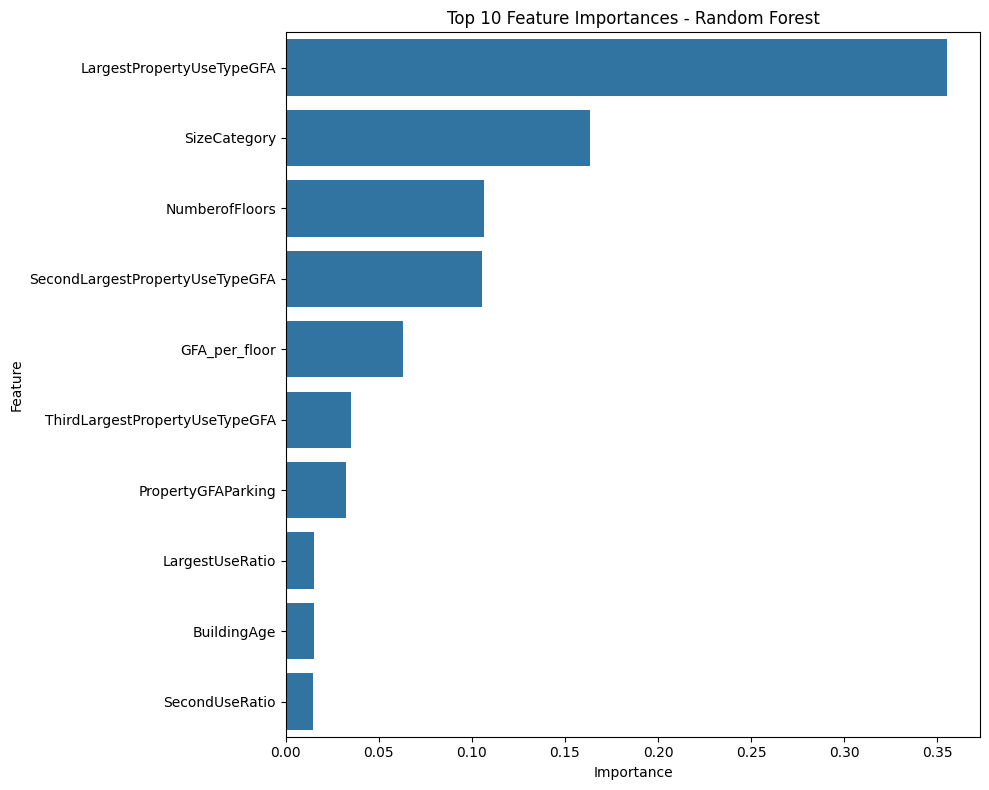

In [67]:
# Recuperer le Random Forest dans le pipeline
rf_model = rf_final.named_steps["rf"]

# Construire le tableau des importances
feat_imp = pd.DataFrame({
    "feature": X_eva_no_energy.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

# Afficher les valeurs
print(feat_imp)

# Histogramme des 10 features les plus importantes
top_n = 10

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feat_imp.head(top_n),
    x="importance",
    y="feature",
    orient="h"
)
plt.title(f"Top {top_n} Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Maintenant on intègre la variable ENERGYScore dans les features comme dernière amélioration possible : 

In [68]:
# Entrainement sur le jeu de dev (avec ENERGYSTARScore)
rf_final.fit(X_eva_with_energy, y1_eva)

# Prediction sur le vrai jeu hold-out final
y1_final_pred = rf_final.predict(X_final_with_energy)

print("R² final :", r2_score(y1_final, y1_final_pred))
print("MAPE final (%) :", mean_absolute_percentage_error(y1_final, y1_final_pred) * 100)
print("MAE final :", mean_absolute_error(y1_final, y1_final_pred))
print("RMSE final :", np.sqrt(mean_squared_error(y1_final, y1_final_pred)))


R² final : 0.7198087848721377
MAPE final (%) : 60.13292751127439
MAE final : 2790398.6302010887
RMSE final : 6106854.712161254


                            feature  importance
0         LargestPropertyUseTypeGFA    0.361246
14                     SizeCategory    0.146585
5                    NumberofFloors    0.099988
1   SecondLargestPropertyUseTypeGFA    0.099761
8                     GFA_per_floor    0.066014
2    ThirdLargestPropertyUseTypeGFA    0.033863
6                PropertyGFAParking    0.033377
3                   ENERGYSTARScore    0.026558
7                       BuildingAge    0.014843
10                  LargestUseRatio    0.013450
11                   SecondUseRatio    0.011609
9                  BuildingGFARatio    0.010402
12                    ThirdUseRatio    0.007799
28            PrimaryPropertyType_4    0.007317
4                 NumberofBuildings    0.005553
26            PrimaryPropertyType_2    0.005071
19              BuildingType_Campus    0.005011
37   SecondLargestPropertyUseType_3    0.004530
18                        UsesSteam    0.004438
25            PrimaryPropertyType_1    0

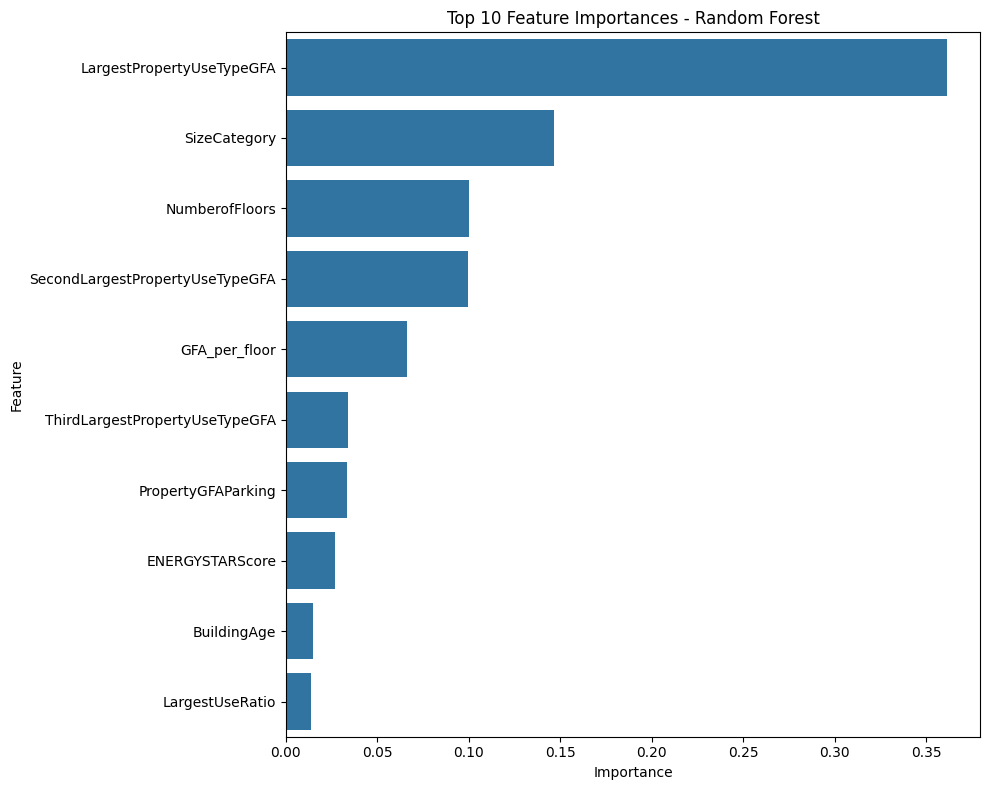

In [69]:
# Recuperer le Random Forest dans le pipeline
rf_model = rf_final.named_steps["rf"]

# Construire le tableau des importances
feat_imp = pd.DataFrame({
    "feature": X_eva_with_energy.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

# Afficher les valeurs
print(feat_imp)

# Histogramme des 10 features les plus importantes
top_n = 10

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feat_imp.head(top_n),
    x="importance",
    y="feature",
    orient="h"
)
plt.title(f"Top {top_n} Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Conclusions 1ere Target

Pour la premiere cible, Random Forest reste le meilleur compromis global parmi les modeles testes, en particulier sur la phase de benchmark.  
L'optimisation orientee sur le MAE donne un MAE de validation croisee de 2,519,238, puis un MAE final de 3,073,746 sur le jeu de test sans ENERGYSTARScore.  

L'ajout de la variable ENERGYSTARScore ameliore les performances finales : le R2 passe a 0.720, le MAE descend a 2,790,399, le RMSE a 6,106,855, et le MAPE diminue a 60.13%.  
Le gain est reel et confirme que cette variable apporte un signal utile pour la prediction de la consommation energetique.



Maintenant on passe à la deuxième target. 

In [70]:
print_cv_results(models, X_eva_no_energy, y2_eva, cv=5)



Dummy
Train | R²: 0.0000 | MAPE: 391.80% | MAE: 120.1086 | RMSE: 244.3198
Test  | R²: -0.0090 | MAPE: 391.30% | MAE: 120.2174 | RMSE: 237.9693

Linear Regression
Train | R²: 0.5709 | MAPE: 187.68% | MAE: 80.2849 | RMSE: 159.7626
Test  | R²: 0.3703 | MAPE: 198.69% | MAE: 88.4958 | RMSE: 182.6466

Polynomial Regression
Train | R²: 0.9882 | MAPE: 51.50% | MAE: 14.8592 | RMSE: 26.3705
Test  | R²: -6021.9080 | MAPE: 9035.33% | MAE: 2927.5671 | RMSE: 8341.3519

Ridge
Train | R²: 0.5708 | MAPE: 187.44% | MAE: 80.2235 | RMSE: 159.7632
Test  | R²: 0.3717 | MAPE: 198.46% | MAE: 88.4057 | RMSE: 182.4925

Lasso
Train | R²: 0.5693 | MAPE: 178.62% | MAE: 78.5915 | RMSE: 160.0579
Test  | R²: 0.3861 | MAPE: 189.24% | MAE: 86.2559 | RMSE: 181.0135

ElasticNet
Train | R²: 0.5202 | MAPE: 147.58% | MAE: 74.9724 | RMSE: 169.0593
Test  | R²: 0.4390 | MAPE: 153.13% | MAE: 78.9245 | RMSE: 176.8980

SVR
Train | R²: -0.0343 | MAPE: 110.22% | MAE: 90.1351 | RMSE: 248.4966
Test  | R²: -0.0377 | MAPE: 113.01% | M

Pour la deuxieme cible, le benchmark initial montre que Random Forest est le modele le plus interessant si l'on retient le MAE comme metrique principale.  
Sur le jeu de test benchmark, il obtient le meilleur MAE (73.60), devant ElasticNet (78.92), XGBoost (80.55) et les modeles lineaires.  

Le MAPE reste eleve pour l'ensemble des modeles, ce qui confirme qu'il doit rester une metrique secondaire d'interpretation.  
Random Forest est donc retenu comme candidat principal pour la phase d'optimisation.



In [71]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "rf__n_estimators": [400, 800],
    "rf__max_depth": [10, 12, 15],
    "rf__min_samples_split": [5, 10],
    "rf__min_samples_leaf": [2, 4, 8],
    "rf__max_features": [0.3],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_eva_no_energy, y2_eva)

print("=== BEST PARAMS ===")
print(grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
=== BEST PARAMS ===
{'rf__max_depth': 12, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 800}
Best CV MAE: 71.93196227234857


In [72]:
rf_no_energy = grid.best_estimator_
y2_final_pred = rf_no_energy.predict(X_final_no_energy)
print("R2 final :", r2_score(y2_final, y2_final_pred))
print("MAPE final (%) :", mean_absolute_percentage_error(y2_final, y2_final_pred) * 100)
print("MAE final :", mean_absolute_error(y2_final, y2_final_pred))
print("RMSE final :", np.sqrt(mean_squared_error(y2_final, y2_final_pred)))


R2 final : 0.5128193674625832
MAPE final (%) : 107.89784746772213
MAE final : 65.52814895691066
RMSE final : 114.6307340244265


Pour la deuxieme cible, l'optimisation du Random Forest sans ENERGYSTARScore ameliore le score de validation croisee, avec un MAE de 71.93.  
Sur le jeu de test final, ce modele atteint un MAE de 65.53, un R2 de 0.513 et un RMSE de 114.63.  

Ces resultats confirment que Random Forest constitue le meilleur choix dans cette configuration lorsque l'on privilegie l'erreur absolue moyenne.



                            feature  importance
0         LargestPropertyUseTypeGFA    0.275557
7                     GFA_per_floor    0.111106
4                    NumberofFloors    0.093733
13                     SizeCategory    0.090399
1   SecondLargestPropertyUseTypeGFA    0.068570
16                        UsesSteam    0.036543
25            PrimaryPropertyType_3    0.032995
9                   LargestUseRatio    0.030234
6                       BuildingAge    0.029476
10                   SecondUseRatio    0.029290
2    ThirdLargestPropertyUseTypeGFA    0.025005
15                          UsesGas    0.021963
5                PropertyGFAParking    0.021213
8                  BuildingGFARatio    0.012566
12                   BuildingAgeCat    0.012549
11                    ThirdUseRatio    0.011676
28                   Neighborhood_1    0.010636
35   SecondLargestPropertyUseType_3    0.008739
39    ThirdLargestPropertyUseType_1    0.008150
31                   Neighborhood_4    0

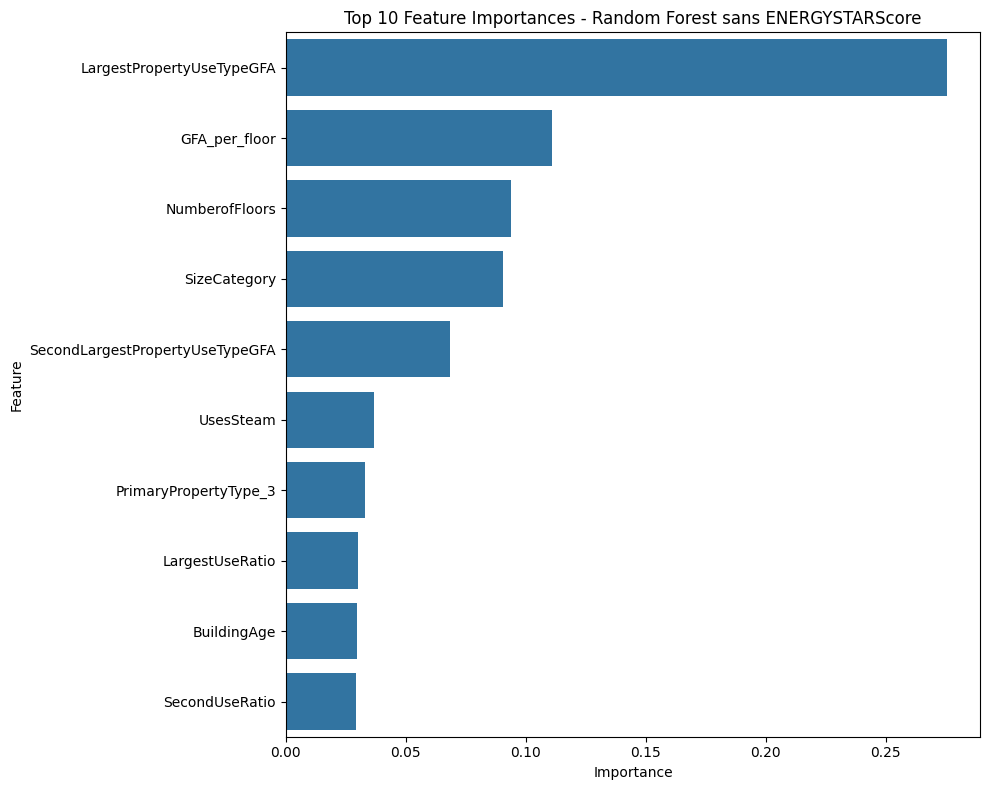

In [73]:
# Recuperer le Random Forest dans le pipeline
rf_model = rf_no_energy.named_steps["rf"]

feat_imp = pd.DataFrame({
    "feature": X_final_no_energy.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feat_imp)

top_n = 10
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feat_imp.head(top_n),
    x="importance",
    y="feature",
    orient="h"
)
plt.title(f"Top {top_n} Feature Importances - Random Forest sans ENERGYSTARScore")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [74]:
grid_rf_with_energy = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_rf_with_energy.fit(X_eva_with_energy, y2_eva)

print("=== BEST PARAMS ===")
print(grid_rf_with_energy.best_params_)
print("Best CV MAE:", -grid_rf_with_energy.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
=== BEST PARAMS ===
{'rf__max_depth': 15, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 400}
Best CV MAE: 69.44723824962125


In [75]:
rf_with_energy = grid_rf_with_energy.best_estimator_
y2_final_pred = rf_with_energy.predict(X_final_with_energy)
print("R2 final :", r2_score(y2_final, y2_final_pred))
print("MAPE final (%) :", mean_absolute_percentage_error(y2_final, y2_final_pred) * 100)
print("MAE final :", mean_absolute_error(y2_final, y2_final_pred))
print("RMSE final :", np.sqrt(mean_squared_error(y2_final, y2_final_pred)))


R2 final : 0.5880988861344709
MAPE final (%) : 109.78711761297646
MAE final : 62.0327198536191
RMSE final : 105.40289735317485


                            feature  importance
0         LargestPropertyUseTypeGFA    0.269782
8                     GFA_per_floor    0.109931
14                     SizeCategory    0.085805
5                    NumberofFloors    0.084228
1   SecondLargestPropertyUseTypeGFA    0.058953
3                   ENERGYSTARScore    0.050836
18                        UsesSteam    0.037234
10                  LargestUseRatio    0.030904
27            PrimaryPropertyType_3    0.030027
7                       BuildingAge    0.027625
2    ThirdLargestPropertyUseTypeGFA    0.027610
11                   SecondUseRatio    0.025374
6                PropertyGFAParking    0.021199
17                          UsesGas    0.018264
9                  BuildingGFARatio    0.011061
12                    ThirdUseRatio    0.010464
13                   BuildingAgeCat    0.010141
33                   Neighborhood_4    0.009909
41    ThirdLargestPropertyUseType_1    0.007900
28            PrimaryPropertyType_4    0

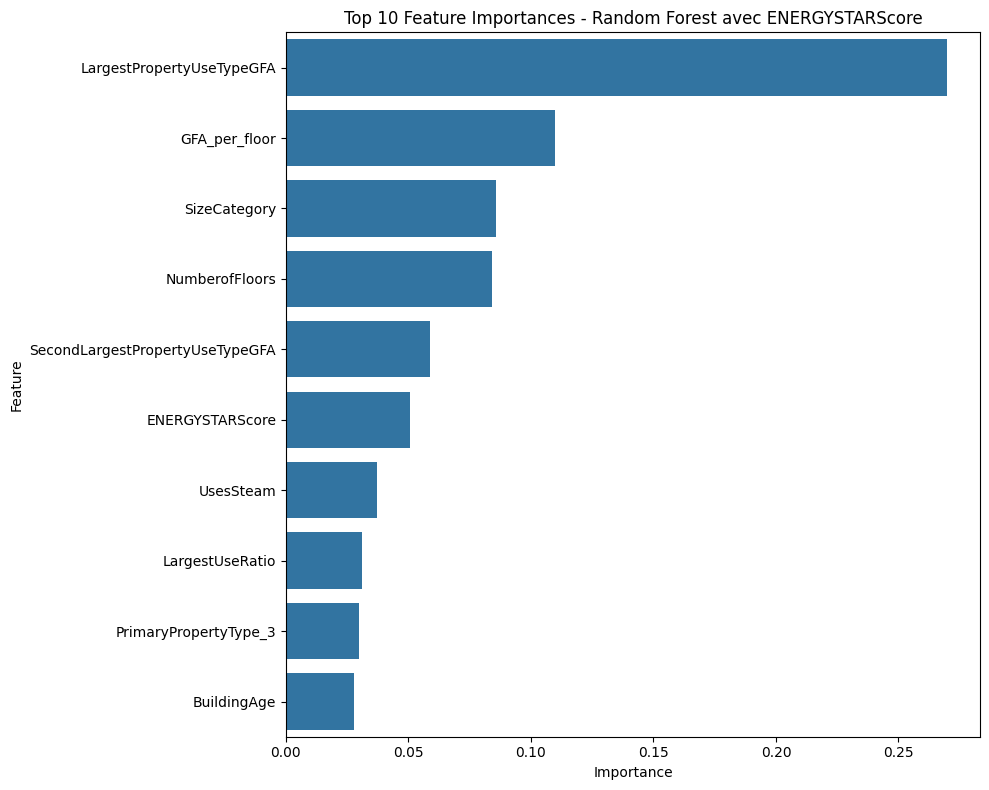

In [76]:
# Recuperer le Random Forest dans le pipeline
rf_model = rf_with_energy.named_steps["rf"]

feat_imp = pd.DataFrame({
    "feature": X_final_with_energy.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feat_imp)

top_n = 10
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feat_imp.head(top_n),
    x="importance",
    y="feature",
    orient="h"
)
plt.title(f"Top {top_n} Feature Importances - Random Forest avec ENERGYSTARScore")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Conclusions deuxieme target :

Le modele retenu est un Random Forest optimise sur le MAE, qui offre le meilleur compromis sur la metrique principale retenue.  

Sans ENERGYSTARScore, le modele atteint un MAE final de 65.53 et un R2 final de 0.513.  
L'ajout de ENERGYSTARScore ameliore les performances globales, avec un MAE final de 62.03 et un R2 final de 0.588.  

ENERGYSTARScore apporte donc un signal utile, avec un gain reel sur la prediction de CO2.



## Conclusion generale

Le notebook a suivi une demarche en plusieurs etapes : preparation des variables explicatives, encodage cible des variables categorielles, separation unique entre jeu d'evaluation et jeu final, comparaison de plusieurs modeles en validation croisee, optimisation du meilleur modele selon la metrique retenue, puis evaluation finale sur un jeu totalement mis de cote.

| Etape | Demarche |
|---|---|
| 1. Preparation des donnees | Utilisation du dataset enrichi issu du feature engineering |
| 2. Encodage | One-hot sur `BuildingType` et `MainEnergySource`, encodage binaire sur les autres variables categorielles |
| 3. Split | Split unique en `90% / 10%` pour conserver un jeu final independant |
| 4. Benchmark | Comparaison de plusieurs modeles en validation croisee (`Dummy`, regressions lineaires, `SVR`, `Random Forest`, `XGBoost`) |
| 5. Selection | Choix du meilleur modele selon la cible et la metrique prioritaire |
| 6. Optimisation | `GridSearchCV` sur le modele retenu |
| 7. Evaluation finale | Test sur le jeu hold-out final, avec et sans `ENERGYSTARScore` |

### Resultats synthetiques

| Cible | Modele retenu | Metrique principale | Resultat CV | Resultat final sans `ENERGYSTARScore` | Resultat final avec `ENERGYSTARScore` |
|---|---|---|---|---|---|
| `EnergyTarget` | `Random Forest` | `MAE` | `MAE CV = 2,519,238.02` | `R2 = 0.698` ; `MAE = 3,073,745.56` ; `MAPE = 63.11%` ; `RMSE = 6,337,808.43` | `R2 = 0.720` ; `MAE = 2,790,398.63` ; `MAPE = 60.13%` ; `RMSE = 6,106,854.71` |
| `CO2Target` | `Random Forest` | `MAE` | `MAE CV = 71.93` sans score ; `69.45` avec score | `R2 = 0.513` ; `MAE = 65.53` ; `MAPE = 107.90%` ; `RMSE = 114.63` | `R2 = 0.588` ; `MAE = 62.03` ; `MAPE = 109.79%` ; `RMSE = 105.40` |

